In [13]:
from typing import TypedDict, List
from langgraph.graph import StateGraph
from numpy.ma.core import multiply

In [14]:
class AgentState(TypedDict):
    name: str
    values: List[int]
    operation: str
    output: str

In [15]:
def arithmatic_operation_node(state: AgentState) -> AgentState:
    state['output'] = f"Hi {state['name']}, your answer is: {perform_arithmatic_operations(state['values'], state['operation'])}"
    return state

def perform_arithmatic_operations(values: List[int], operation: str) -> int:
    if operation == "+":
        return sum(values)
    elif operation == "*":
        return multiply(values)
    else:
        raise ValueError(f"Unsupported operation: {operation}")

def multiply(values: List[int]) ->int:
    multi_result = 1
    for value in values:
        multi_result *= value
    return multi_result

In [16]:
graph = StateGraph(AgentState)

graph.add_node("arithimatic_operator", arithmatic_operation_node)
graph.set_entry_point("arithimatic_operator")
graph.set_finish_point("arithimatic_operator")

app = graph.compile()

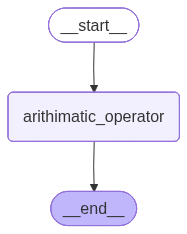

In [17]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [18]:
result = app.invoke({
    "name": "Jack Sparrow",
    "values": [1, 2, 3, 4],
    "operation": "*"
})
result["output"]

'Hi Jack Sparrow, your answer is: 24'